# Advanced Data Mining for Data-Driven Insights and Predictive Modeling

## Project Deliverable 2: Regression Modeling and Performance Evaluation

**Course:** 2026 Summer - Advanced Big Data and Data Mining  
**Course Number:** MSCS-634-M20  
**Date:** July 24-26, 2026  
**Dataset:** Credit Card Fraud Detection  
**Dataset Source:** [Credit Card Fraud Detection on Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

**Group Members:**  
Ashish Mahajan  
Murali Krishna Vattikunta  
Sreesh Sattiyamourthy  
Sreeharsha Varma Tinnanuri

### Purpose

This deliverable evaluates how well anonymized transaction characteristics and time-derived features estimate transaction `Amount`. Linear Regression provides an unregularized baseline, while Ridge Regression tests whether coefficient shrinkage improves generalization.

### Objectives

- Create cyclical time features and a compact PCA magnitude feature.
- Prevent leakage by splitting before fitting preprocessing and excluding `Amount`, `LogAmount`, and `Class` from predictors.
- compare Linear and cross-validated Ridge Regression.
- Evaluate predictions in the original dollar scale with MAE, MSE, RMSE, and R-squared.

### Dataset and Ethical Note

Only the approved Kaggle dataset is used. The PCA variables are anonymized, so coefficient interpretation is limited to relative statistical influence. Regression estimates are analytical results, not transaction or customer judgments.

### Notebook Roadmap

1. Load and clean the dataset using the Deliverable 1 rule.
2. Engineer regression features and create an 80/20 split.
3. train Linear and Ridge pipelines with a log-transformed target.
4. compare cross-validation and untouched test-set metrics.
5. save and interpret the required tables and visualizations.

## 1. Setup and Reproducible Data Loading

**Objective:** Import only required libraries, create output directories, validate the approved dataset schema, and remove exact duplicates using the same rule as Deliverable 1.

In [1]:
import shutil
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
PCA_COLUMNS = [f"V{number}" for number in range(1, 29)]
REQUIRED_COLUMNS = ["Time", *PCA_COLUMNS, "Amount", "Class"]

Path("data").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)
Path("images/deliverable_2").mkdir(parents=True, exist_ok=True)

def load_credit_card_data():
    dataset_path = next(
        (path for path in (Path("data/creditcard.csv"), Path("creditcard.csv")) if path.is_file()),
        None,
    )
    if dataset_path is None:
        download_path = Path(kagglehub.dataset_download("mlg-ulb/creditcardfraud"))
        matches = list(download_path.rglob("creditcard.csv"))
        if len(matches) != 1:
            raise FileNotFoundError("Download creditcard.csv from Kaggle and place it in data/.")
        dataset_path = Path("data/creditcard.csv")
        shutil.copy2(matches[0], dataset_path)
    dataframe = pd.read_csv(dataset_path)
    if dataframe.columns.tolist() != REQUIRED_COLUMNS:
        raise ValueError("Dataset columns do not match the approved credit-card dataset.")
    return dataframe, dataset_path

def save_figure(path):
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

raw_df, dataset_path = load_credit_card_data()
clean_df = raw_df.drop_duplicates().reset_index(drop=True)
print(f"Loaded: {dataset_path}")
print(f"Cleaned shape: {clean_df.shape[0]:,} rows x {clean_df.shape[1]} columns")

Loaded: data/creditcard.csv
Cleaned shape: 283,726 rows x 31 columns


**Interpretation:** Exact-duplicate removal prevents repeated transactions from influencing the regression fit. Statistical extremes are retained because large transaction amounts are valid observations and are central to the prediction question.

## 2. Feature Engineering and Train-Test Split

**Objective:** Represent time cyclically, retain day position, and summarize PCA magnitude. `Class` is excluded because fraud status must not be used to estimate transaction amount, and preprocessing is fitted only inside model pipelines.

In [2]:
regression_df = clean_df.copy()
regression_df["Hour"] = (regression_df["Time"] / 3600) % 24
regression_df["DayIndex"] = np.floor(regression_df["Time"] / 86400).astype(int)
regression_df["HourSin"] = np.sin(2 * np.pi * regression_df["Hour"] / 24)
regression_df["HourCos"] = np.cos(2 * np.pi * regression_df["Hour"] / 24)
regression_df["PCA_L2_Norm"] = np.sqrt(
    np.square(regression_df[PCA_COLUMNS]).sum(axis=1)
)

feature_columns = [
    *PCA_COLUMNS,
    "Hour",
    "DayIndex",
    "HourSin",
    "HourCos",
    "PCA_L2_Norm",
]
X = regression_df[feature_columns]
y = regression_df["Amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)
prediction_upper_bound = y_train.quantile(0.999)
target_log_upper_bound = np.log1p(prediction_upper_bound)

split_summary = pd.DataFrame({
    "Partition": ["Training", "Test"],
    "Rows": [len(X_train), len(X_test)],
    "Percentage": [len(X_train) / len(X) * 100, len(X_test) / len(X) * 100],
})
display(split_summary.style.format({"Rows": "{:,.0f}", "Percentage": "{:.2f}%"}))
print("Predictors excluded:", ["Amount", "LogAmount", "Class"])
print(f"Training-derived prediction upper bound: ${prediction_upper_bound:,.2f}")

,Partition,Rows,Percentage
0,Training,"226,980",80.00%
1,Test,"56,746",20.00%


Predictors excluded: ['Amount', 'LogAmount', 'Class']
Training-derived prediction upper bound: $3,000.00


**Interpretation:** `HourSin` and `HourCos` preserve the circular relationship between late-night and early-morning hours. `PCA_L2_Norm` captures overall transformed-feature magnitude without replacing the individual PCA variables. The target is highly right-skewed, so each model learns `log1p(Amount)` internally and converts predictions back to dollars before scoring. Inverse-transformed model outputs are constrained from zero to the training-derived 99.9th amount percentile. This does not alter target values; it prevents unsupported numerical extrapolation and uses no test information.

## 3. Regression Models and Cross-Validation

**Objective:** Build standardized pipelines and select Ridge `alpha` using five-fold cross-validation on training data only. KFold shuffling with `random_state=42` makes the folds reproducible.

In [3]:
def transformed_regressor(model):
    def inverse_log_amount(values):
        bounded_values = np.clip(values, 0.0, target_log_upper_bound)
        return np.expm1(bounded_values)

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model),
    ])
    return TransformedTargetRegressor(
        regressor=pipeline,
        func=np.log1p,
        inverse_func=inverse_log_amount,
        check_inverse=False,
    )

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"rmse": "neg_root_mean_squared_error", "r2": "r2"}

linear_model = transformed_regressor(LinearRegression())
linear_cv = cross_validate(
    linear_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)
linear_model.fit(X_train, y_train)

ridge_search = GridSearchCV(
    estimator=transformed_regressor(Ridge()),
    param_grid={"regressor__model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
ridge_search.fit(X_train, y_train)
ridge_model = ridge_search.best_estimator_
selected_alpha = ridge_search.best_params_["regressor__model__alpha"]

ridge_cv = cross_validate(
    ridge_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)

alpha_results = pd.DataFrame(ridge_search.cv_results_)[[
    "param_regressor__model__alpha",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]].rename(columns={
    "param_regressor__model__alpha": "Alpha",
    "mean_test_score": "Mean Negative RMSE",
    "std_test_score": "RMSE Score Standard Deviation",
    "rank_test_score": "Rank",
}).sort_values("Rank")

print(f"Selected Ridge alpha: {selected_alpha}")
display(alpha_results.style.format({
    "Alpha": "{:.2f}",
    "Mean Negative RMSE": "{:.4f}",
    "RMSE Score Standard Deviation": "{:.4f}",
    "Rank": "{:.0f}",
}))

Selected Ridge alpha: 100.0


,Alpha,Mean Negative RMSE,RMSE Score Standard Deviation,Rank
4,100.00,-178.4252,16.2127,1
3,10.00,-178.6439,16.2024,2
2,1.00,-178.6659,16.2020,3
1,0.10,-178.6681,16.2020,4
0,0.01,-178.6683,16.2020,5


**Interpretation:** The alpha grid is intentionally small and transparent. Selection uses only training folds, preventing the test set from influencing model choice.

## 4. Test-Set Evaluation

**Objective:** Compare both fitted models on the untouched test partition. MAE, MSE, and RMSE are calculated after inverse transformation, so their units are dollars.

In [4]:
models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
}
predictions = {name: model.predict(X_test) for name, model in models.items()}

metric_rows = []
for name, y_pred in predictions.items():
    mse = mean_squared_error(y_test, y_pred)
    metric_rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_test, y_pred),
        "Selected Alpha": selected_alpha if name == "Ridge Regression" else np.nan,
    })

regression_metrics = pd.DataFrame(metric_rows).sort_values("RMSE").reset_index(drop=True)
regression_metrics.to_csv("results/regression_metrics.csv", index=False)

cv_rows = []
for name, scores in {
    "Linear Regression": linear_cv,
    "Ridge Regression": ridge_cv,
}.items():
    cv_rows.append({
        "Model": name,
        "CV RMSE Mean": -scores["test_rmse"].mean(),
        "CV RMSE Standard Deviation": scores["test_rmse"].std(ddof=1),
        "CV R2 Mean": scores["test_r2"].mean(),
        "CV R2 Standard Deviation": scores["test_r2"].std(ddof=1),
        "Selected Alpha": selected_alpha if name == "Ridge Regression" else np.nan,
    })
regression_cv_metrics = pd.DataFrame(cv_rows)
regression_cv_metrics.to_csv("results/regression_cv_metrics.csv", index=False)

display(regression_metrics.style.format({
    "MAE": "${:,.4f}",
    "MSE": "{:,.4f}",
    "RMSE": "${:,.4f}",
    "R2": "{:.4f}",
    "Selected Alpha": "{:.2f}",
}))
display(regression_cv_metrics.style.format({
    "CV RMSE Mean": "${:,.4f}",
    "CV RMSE Standard Deviation": "${:,.4f}",
    "CV R2 Mean": "{:.4f}",
    "CV R2 Standard Deviation": "{:.4f}",
    "Selected Alpha": "{:.2f}",
}))

,Model,MAE,MSE,RMSE,R2,Selected Alpha
0,Ridge Regression,$57.9663,"27,380.4555",$165.4704,0.5332,100.00
1,Linear Regression,$57.9788,"27,463.3800",$165.7208,0.5318,nan


,Model,CV RMSE Mean,CV RMSE Standard Deviation,CV R2 Mean,CV R2 Standard Deviation,Selected Alpha
0,Linear Regression,$178.6683,$18.1143,0.4986,0.0515,nan
1,Ridge Regression,$178.4252,$18.1263,0.4999,0.0516,100.00


## 5. Coefficients and Required Visualizations

**Objective:** Inspect standardized log-target coefficients and visualize prediction fit, residual behavior, metric comparison, and Ridge feature influence. Coefficients show relative model influence, not causal business effects.

,Feature,Ridge Regression
1,V2,-0.9112
32,PCA_L2_Norm,-0.8443
0,V1,-0.7205
4,V5,-0.5698
2,V3,-0.3906
15,V16,-0.2171
7,V8,-0.2132
11,V12,-0.1912
14,V15,-0.1225
31,HourCos,-0.0887


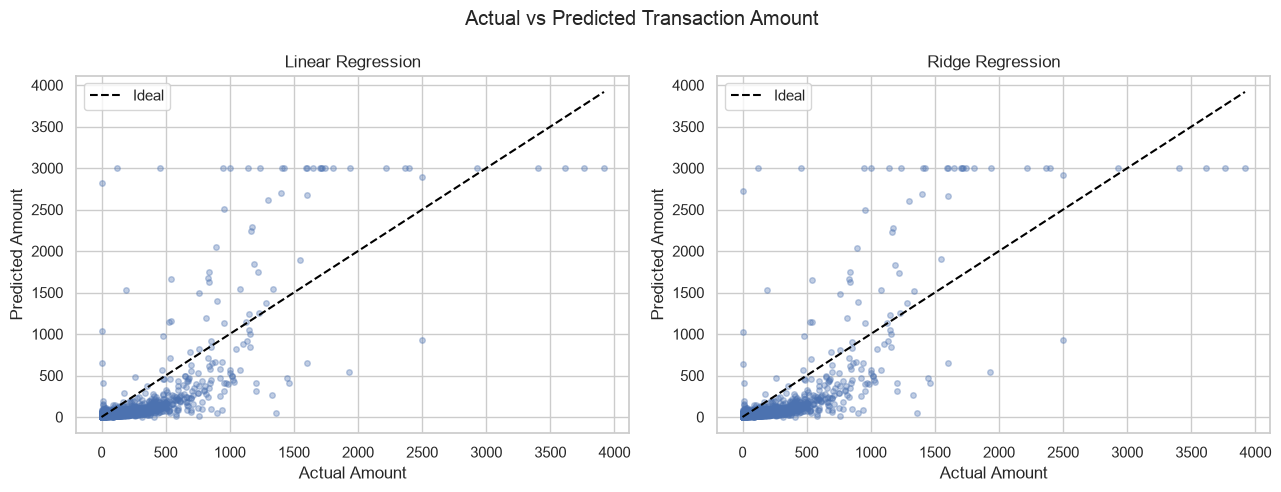

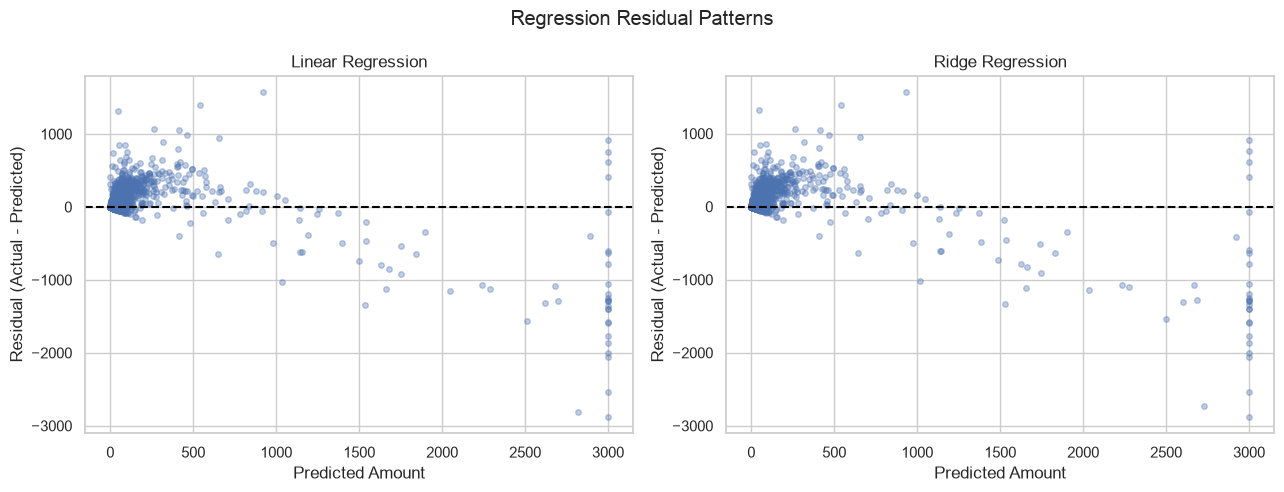

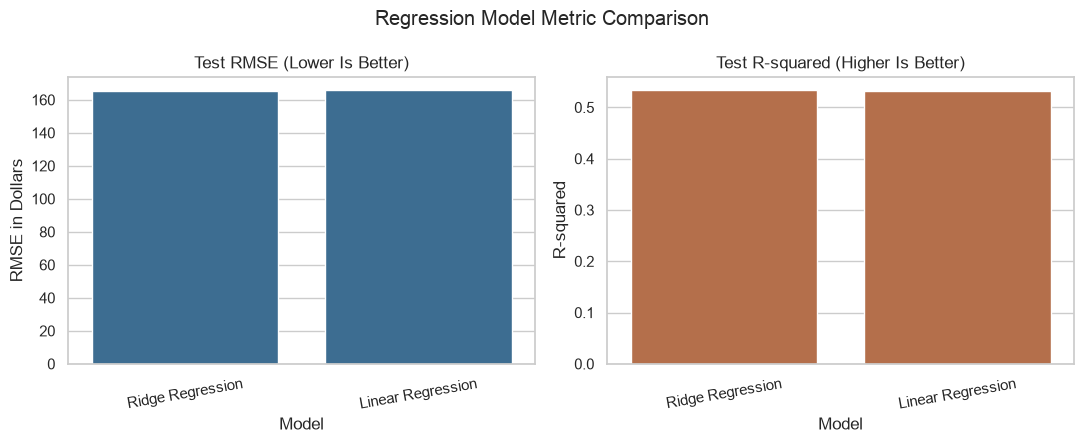

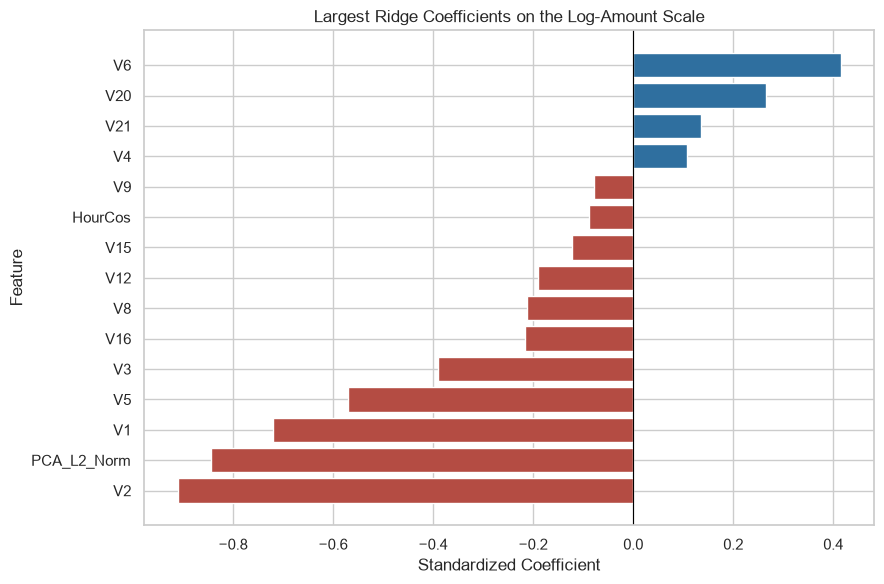

In [5]:
coefficient_table = pd.DataFrame({"Feature": feature_columns})
for name, model in models.items():
    coefficient_table[name] = model.regressor_.named_steps["model"].coef_
coefficient_table.to_csv("results/regression_coefficients.csv", index=False)

ridge_top = (
    coefficient_table.assign(
        Absolute_Coefficient=coefficient_table["Ridge Regression"].abs()
    )
    .nlargest(15, "Absolute_Coefficient")
    .sort_values("Ridge Regression")
)
display(ridge_top[["Feature", "Ridge Regression"]].style.format({
    "Ridge Regression": "{:.4f}"
}))

sample_positions = (
    pd.Series(np.arange(len(X_test)))
    .sample(n=min(5000, len(X_test)), random_state=RANDOM_STATE)
    .sort_values()
    .to_numpy()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for axis, (name, y_pred) in zip(axes, predictions.items()):
    actual_sample = y_test.iloc[sample_positions]
    predicted_sample = y_pred[sample_positions]
    axis.scatter(actual_sample, predicted_sample, s=16, alpha=0.35)
    low = min(actual_sample.min(), predicted_sample.min())
    high = max(actual_sample.max(), predicted_sample.max())
    axis.plot([low, high], [low, high], color="black", linestyle="--", label="Ideal")
    axis.set(title=name, xlabel="Actual Amount", ylabel="Predicted Amount")
    axis.legend()
fig.suptitle("Actual vs Predicted Transaction Amount")
save_figure("images/deliverable_2/01_actual_vs_predicted.png")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for axis, (name, y_pred) in zip(axes, predictions.items()):
    residuals = y_test.to_numpy()[sample_positions] - y_pred[sample_positions]
    axis.scatter(y_pred[sample_positions], residuals, s=16, alpha=0.35)
    axis.axhline(0, color="black", linestyle="--")
    axis.set(title=name, xlabel="Predicted Amount", ylabel="Residual (Actual - Predicted)")
fig.suptitle("Regression Residual Patterns")
save_figure("images/deliverable_2/02_residual_plot.png")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.barplot(data=regression_metrics, x="Model", y="RMSE", ax=axes[0], color="#2f6f9f")
sns.barplot(data=regression_metrics, x="Model", y="R2", ax=axes[1], color="#c56a3a")
axes[0].set_title("Test RMSE (Lower Is Better)")
axes[0].set_ylabel("RMSE in Dollars")
axes[1].set_title("Test R-squared (Higher Is Better)")
axes[1].set_ylabel("R-squared")
for axis in axes:
    axis.tick_params(axis="x", rotation=10)
fig.suptitle("Regression Model Metric Comparison")
save_figure("images/deliverable_2/03_model_metric_comparison.png")

plt.figure(figsize=(9, 6))
colors = ["#b44c43" if value < 0 else "#2f6f9f" for value in ridge_top["Ridge Regression"]]
plt.barh(ridge_top["Feature"], ridge_top["Ridge Regression"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Largest Ridge Coefficients on the Log-Amount Scale")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Feature")
save_figure("images/deliverable_2/04_ridge_coefficients.png")

## 6. Final Interpretation and Recommendation

**Objective:** Base the recommendation directly on the saved metrics and explain what the result means for this dataset and feature design.

In [6]:
best_rmse_row = regression_metrics.loc[regression_metrics["RMSE"].idxmin()]
best_r2_row = regression_metrics.loc[regression_metrics["R2"].idxmax()]
ridge_row = regression_metrics.query("Model == 'Ridge Regression'").iloc[0]
linear_row = regression_metrics.query("Model == 'Linear Regression'").iloc[0]
ridge_cv_row = regression_cv_metrics.query("Model == 'Ridge Regression'").iloc[0]
influential_features = ridge_top.iloc[
    ridge_top["Ridge Regression"].abs().argsort()[::-1]
]["Feature"].head(5).tolist()

print(f"Lower test RMSE: {best_rmse_row['Model']} (${best_rmse_row['RMSE']:,.4f})")
print(f"Higher test R-squared: {best_r2_row['Model']} ({best_r2_row['R2']:.4f})")
print(
    "Ridge generalization change versus Linear: "
    f"RMSE {ridge_row['RMSE'] - linear_row['RMSE']:+.4f}, "
    f"R-squared {ridge_row['R2'] - linear_row['R2']:+.4f}"
)
print(
    f"Ridge cross-validation RMSE: ${ridge_cv_row['CV RMSE Mean']:,.4f} "
    f"+/- ${ridge_cv_row['CV RMSE Standard Deviation']:,.4f}"
)
print("Largest absolute Ridge coefficients:", ", ".join(influential_features))
print(
    f"Recommendation: use {best_rmse_row['Model']} as the stronger regression baseline "
    "in this run because it produced the lowest untouched-test RMSE. "
    "The result remains limited by the anonymized features and large amount extremes."
)

Lower test RMSE: Ridge Regression ($165.4704)
Higher test R-squared: Ridge Regression (0.5332)
Ridge generalization change versus Linear: RMSE -0.2504, R-squared +0.0014
Ridge cross-validation RMSE: $178.4252 +/- $18.1263
Largest absolute Ridge coefficients: V2, PCA_L2_Norm, V1, V5, V6
Recommendation: use Ridge Regression as the stronger regression baseline in this run because it produced the lowest untouched-test RMSE. The result remains limited by the anonymized features and large amount extremes.


### Findings, Challenges, and Limitations

- The test and cross-validation tables determine whether Ridge improved generalization; the recommendation does not assume regularization must win.
- A low or limited R-squared is still valid evidence: under this feature design, anonymized transaction characteristics may not fully explain dollar amount.
- Log-target fitting reduces the influence of extreme amounts, while the training-derived prediction bound prevents unstable extrapolation. This can still underpredict rare transactions above that bound.
- PCA coefficients identify statistical influence on transformed amount, but anonymization prevents direct business interpretation or causal claims.
- Extreme transactions were retained, so error metrics honestly reflect the difficulty of predicting the full observed amount range.

**Connection to Deliverable 3:** The next deliverable changes the target to fraud `Class`, uses stratification and imbalance-aware metrics, and keeps the regression test findings separate from fraud classification.